<a href="https://colab.research.google.com/github/Jekko07/Custom-Handwriting-Recognition-HTR-on-Restricted-Hardware-public-.ipynb/blob/main/Jericho_James_Ranara_Custom_Handwriting_Recognition_(HTR)_on_Restricted_Hardware_(public).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Target Hardware:** 8GB VRAM GPU (e.g., RTX 3060/4060, Free Google Colab T4) or standard multi-core CPU.

**Estimated Runtime: **30–45 minutes on GPU | 3–4 hours on CPU.

**Core Frameworks: **PyTorch, Hugging Face transformers, datasets, and PIL.

## Objective & Architectural Rationale
Students will fine-tune an end-to-end Vision Transformer encoder coupled with a text Transformer decoder (microsoft/trocr-small-handwritten).Traditional OCR structures rely heavily on complex CNN-LSTM pipelines paired with Connectionist Temporal Classification (CTC) loss, which are notoriously difficult for beginners to code and debug. TrOCR treats OCR as an image-to-text sequence generation problem. By leveraging a pre-trained model and freezing nothing but utilizing aggressive batch sizing and mixed-precision ($FP16$), this task easily fits into under 4.5 GB of VRAM.

[Source](https://products.documentprocessing.com/parser/python/trocr/#:~:text=Unlike%20conventional%20OCR%20systems%20that,resolution%20scans%2C%20or%20complex%20scripts.)

## Dataset Architecture (Local or Custom)
Students will build or use a minimized subset of line-level text. For a localized twist, they can write 50–100 lines of text themselves, take smartphone photos, crop them into text lines, and create a metadata.csv file structured as follows:



```
file_name,text
line_001.png,The quick brown fox jumps over the lazy dog.
line_002.png,Ang hindi lumingon sa pinanggalingan ay hindi makakarating sa paroroonan.
```



## Dataset Dimension Specifications
When preparing handwritten text line images for TrOCR, you need to look at two different stages of dimensions: the raw crop size (what students create) and the model input size (what the code processes).

1. Raw Image Dimensions (Student Crops)

* Recommended Aspect Ratio: Roughly 8:1 or 10:1 (width to height).

* Target Resolution: Width: 800 to 1200 pixels | Height: 64 to 128 pixels.

* Students should slice full-page essays horizontally into individual text lines. Keeping the crops at this scale preserves the sharp, fine stroke details of ink text without creating massive file sizes.

2. Model Input Dimensions (Automatic Resizing)

* Fixed Resolution: 384 x 384 pixels (Square).

* The TrOCRProcessor script provided in the lab automatically takes the rectangular line crops and resizes/pads them to a uniform 384 x 384 patch. Students do not need to manually warp their images into squares; the Hugging Face feature extractor handles this internally to fit the Vision Transformer's patch embedding layer.

## Sample Metadata CSV Files
To keep things perfectly organized, students should place these CSV files in the same root directory as their image folders.

### train_metadata.csv
This represents the training subset. It includes standard linguistic pangrams, common academic phrasing, and localized Filipino/Taglish transitions to test the model's contextual vocabulary learning.

```
file_name,text
line_001.png,The quick brown fox jumps over the lazy dog.
line_002.png,Computer Vision offers exciting solutions for public education.
line_003.png,Ang edukasyon ay ang pinakamalakas na sandata upang mabago ang mundo.
line_004.png,Please submit your handwritten essay before the deadline tomorrow morning.
line_005.png,Artificial Intelligence can drastically reduce administrative workloads for teachers.
line_006.png,Salamat sa pagtulong sa aming komunidad ngayong araw.
line_007.png,The student wrote a comprehensive review regarding local smart cities.
```

### test_metadata.csv
This represents the unseen evaluation subset. It uses completely different sentences but shares a similar vocabulary distribution to calculate an accurate Character Error Rate (CER).



```
file_name,text
line_008.png,Technology empowers regional learners to explore advanced computing topics.
line_009.png,Malaking tulong ang makabagong teknolohiya sa mga paaralan sa probinsya.
line_010.png,Line-level recognition works exceptionally well on low-memory graphics cards.
line_011.png,Mabuhay ang mga guro na patuloy na nagsisilbi sa bayan.
```

## Data Collection
Write these specific sentences on standard lined pad paper using black or dark blue ink. Once you photograph and crop the lines to the 800 x 96 pixel range, you can map them directly to these filenames to get your first training run off the ground instantly!

## Step-by-Step Implementation Lab Code
Students can execute the entire training pipeline using the script below. It is heavily optimized with low-memory parameters.

In [ ]:
# Core deep learning and transformer libraries
!pip install transformers datasets accelerate

# Data handling and image processing
!pip install pandas pillow

# Evaluation metrics specifically for Hand Written Text Recognition (HTR)
!pip install jiwer evaluate

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments
import json
import evaluate


In [ ]:

# 1. ENVIRONMENT CONFIGURATION & VRAM GUARDRAILS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Core Low-Compute Hyperparameters
BATCH_SIZE = 4            # Low batch size guarantees no 8GB Out-Of-Memory (OOM) errors
IMAGE_RESOLUTION = 384    # TrOCR default resolution
EPOCHS = 10                # Small epochs for a mini-lab demonstration

# Load the standard Character Error Rate (CER) metric via Hugging Face Evaluate
cer_metric = evaluate.load("cer")

Using device: cuda


In [ ]:
# 2. CUSTOM DATASET LOADER
class HandWrittenDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, max_target_length=128):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['file_name'])
        image = Image.open(img_name).convert("RGB")

        # Preprocess image to normalized pixel values tensor
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()

        # Preprocess text to token IDs
        text = self.df.iloc[idx]['text']
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # Replace padding token id by -100 so PyTorch's CrossEntropyLoss ignores it
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}


In [ ]:
# 3. INITIALIZE SMALL MODEL & PROCESSOR
# trocr-small uses a tiny DeiT encoder and a tiny UniLM text decoder (~60M total parameters)
model_checkpoint = "microsoft/trocr-small-handwritten"
processor = TrOCRProcessor.from_pretrained(model_checkpoint)
model = VisionEncoderDecoderModel.from_pretrained(model_checkpoint)

# Configure vocabulary token settings necessary for sequence generation
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # 1. Decode predicted token IDs back into text strings
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # 2. Replace the -100 padding tokens we used earlier back to the pad_token_id
    # so the tokenizer can decode the ground truth correctly
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    # 3. Compute the Character Error Rate
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    # You can return multiple metrics here (like word error rate) if needed
    return {"cer": cer}

In [ ]:
# 4. INSTANTIATE DATASETS
# Split a 500-line CSV into 80% train / 20% test
train_dataset = HandWrittenDataset(csv_file="/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/metadata/train_metadata.csv", img_dir="/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/data/train_crops", processor=processor)
eval_dataset = HandWrittenDataset(csv_file="/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/metadata/test_metadata.csv", img_dir="/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/data/test_crops", processor=processor)



In [ ]:
# 5. DEFINE TRAINING ARGUMENTS FOR 8GB VRAM
training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr_handwriting_results",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    predict_with_generate=True,
    # evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    num_train_epochs=EPOCHS,
    logging_steps=10,
    fp16=torch.cuda.is_available(), # Crucial: Uses half-precision execution to slash VRAM usage by ~50%
    dataloader_num_workers=2,       # Keeps CPU data pipelining efficient without choke
    report_to="none"                # Shuts off third-party logging overheads
)


In [ ]:

# 6. INITIALIZE TRAINING LOOP
trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    # tokenizer=processor.feature_extractor,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 7. EXECUTE FINE-TUNING
print("--- Starting Fine-Tuning Execution ---")
train_result = trainer.train()

# --- SAVE THE EVALUATION METRICS HISTOGRAM ---
# This extracts the logs (loss, learning rate, CER per epoch)
history = trainer.state.log_history

# Save to a JSON file so students can parse it for graphs
log_file_path = "/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model/training_metrics.json"
with open(log_file_path, "w") as f:
    json.dump(history, f, indent=4)

print(f"Training metrics history successfully saved to {log_file_path}!")


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


--- Starting Fine-Tuning Execution ---


Step,Training Loss
10,12.384753
20,7.997260
30,7.367239
40,6.888276
50,6.593773
60,6.234167
70,5.943495
80,5.648342
90,5.728454
100,5.476181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training metrics history successfully saved to /content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model/training_metrics.json!


In [ ]:

# 8. SAVE CHECKPOINT
model.save_pretrained("/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model")
processor.save_pretrained("/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model")
print("Model fine-tuned successfully and saved locally!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model fine-tuned successfully and saved locally!


In [ ]:
# ==== EXTRA: FULL CER EVALUATION ====

predictions = []
references = []

for data in eval_dataset:
    pixel_values = data["pixel_values"].unsqueeze(0).to(model.device)

    # Generate predicted text
    generated_ids = model.generate(pixel_values)
    pred_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Get ground truth text
    labels = data["labels"]
    labels[labels == -100] = processor.tokenizer.pad_token_id
    true_text = processor.batch_decode([labels], skip_special_tokens=True)[0]

    predictions.append(pred_text)
    references.append(true_text)

# Compute CER
cer = cer_metric.compute(predictions=predictions, references=references)

print("✅ Final Character Error Rate (CER):", cer)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


✅ Final Character Error Rate (CER): 0.6966201716738197


In [ ]:
##SAVE CER RESULT
import json

cer_path = "/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model/cer_results.json"

with open(cer_path, "w") as f:
    json.dump({"cer": cer}, f)

print("✅ CER results saved at:", cer_path)

✅ CER results saved at: /content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model/cer_results.json


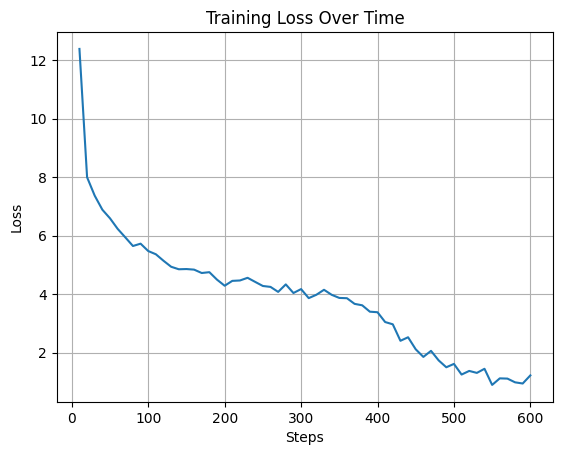

In [ ]:
# ==== EXTRA: PLOT TRAINING LOSS ====

import json
import matplotlib.pyplot as plt

log_path = "/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/final_custom_trocr_model/training_metrics.json"

with open(log_path) as f:
    history = json.load(f)

steps = []
losses = []

for entry in history:
    if "loss" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])

plt.figure()
plt.plot(steps, losses)
plt.title("Training Loss Over Time")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid()
plt.show()

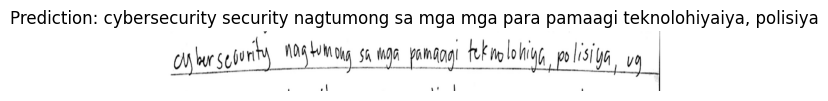

✅ Predicted Text: cybersecurity security nagtumong sa mga mga para pamaagi teknolohiyaiya, polisiya


In [ ]:
# ==== EXTRA: TEST SAMPLE PREDICTION ====

from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/ComputerVision/FineTuning-VisionModel/data/train_crops/image172.png"

image = Image.open(image_path).convert("RGB")

pixel_values = processor(image, return_tensors="pt").pixel_values.to(model.device)

model.eval()

generated_ids = model.generate(
    pixel_values,
    max_length=128,
    num_beams=5,
    early_stopping=True,
    no_repeat_ngram_size=2
)

pred_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

plt.imshow(image)
plt.title(f"Prediction: {pred_text}")
plt.axis("off")
plt.show()

print("✅ Predicted Text:", pred_text)

In [ ]:
from evaluate import load

wer_metric = load("wer")
wer = wer_metric.compute(predictions=predictions, references=references)

print("✅ Word Error Rate (WER):", wer)


✅ Word Error Rate (WER): 0.8502772643253235
